# Industry DSR Impact Analysis

**Apples-to-apples comparison** of two model runs with identical temporal industrial demand profiles:

- **Reference**: Temporal industrial demand, NO DSR (`EU_test_run_temporal_no_dsr`)
- **DSR v3**: Temporal industrial demand + Industry DSR (`EU_test_run_dsr_v3_optional`)

Both runs use: 33 EU countries, 38 clusters, 2030 horizon, full year 2019 (2h resolution).

**Key metrics**: System cost, electricity prices, generation capacity, renewable curtailment, DSR utilization.

In [2]:
import pypsa
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams.update({
    'figure.figsize': (12, 5),
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

# Load networks
print('Loading Reference (temporal, no DSR)...')
n_ref = pypsa.Network('results/EU_test_run_temporal_no_dsr/networks/base_s_38___2030.nc')
print('Loading DSR v3 (temporal + DSR)...')
n_dsr = pypsa.Network('results/EU_test_run_dsr_v3_optional/networks/base_s_38___2030.nc')
print('Done.')

Loading Reference (temporal, no DSR)...


INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, stores, sub_networks


Loading DSR v3 (temporal + DSR)...


INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, stores, sub_networks


Done.


## 1. System Cost (Objective Value)

Reference (no DSR): 617.18 billion EUR
DSR v3:             613.33 billion EUR
DSR impact:         -3.85 billion EUR (-0.62%)


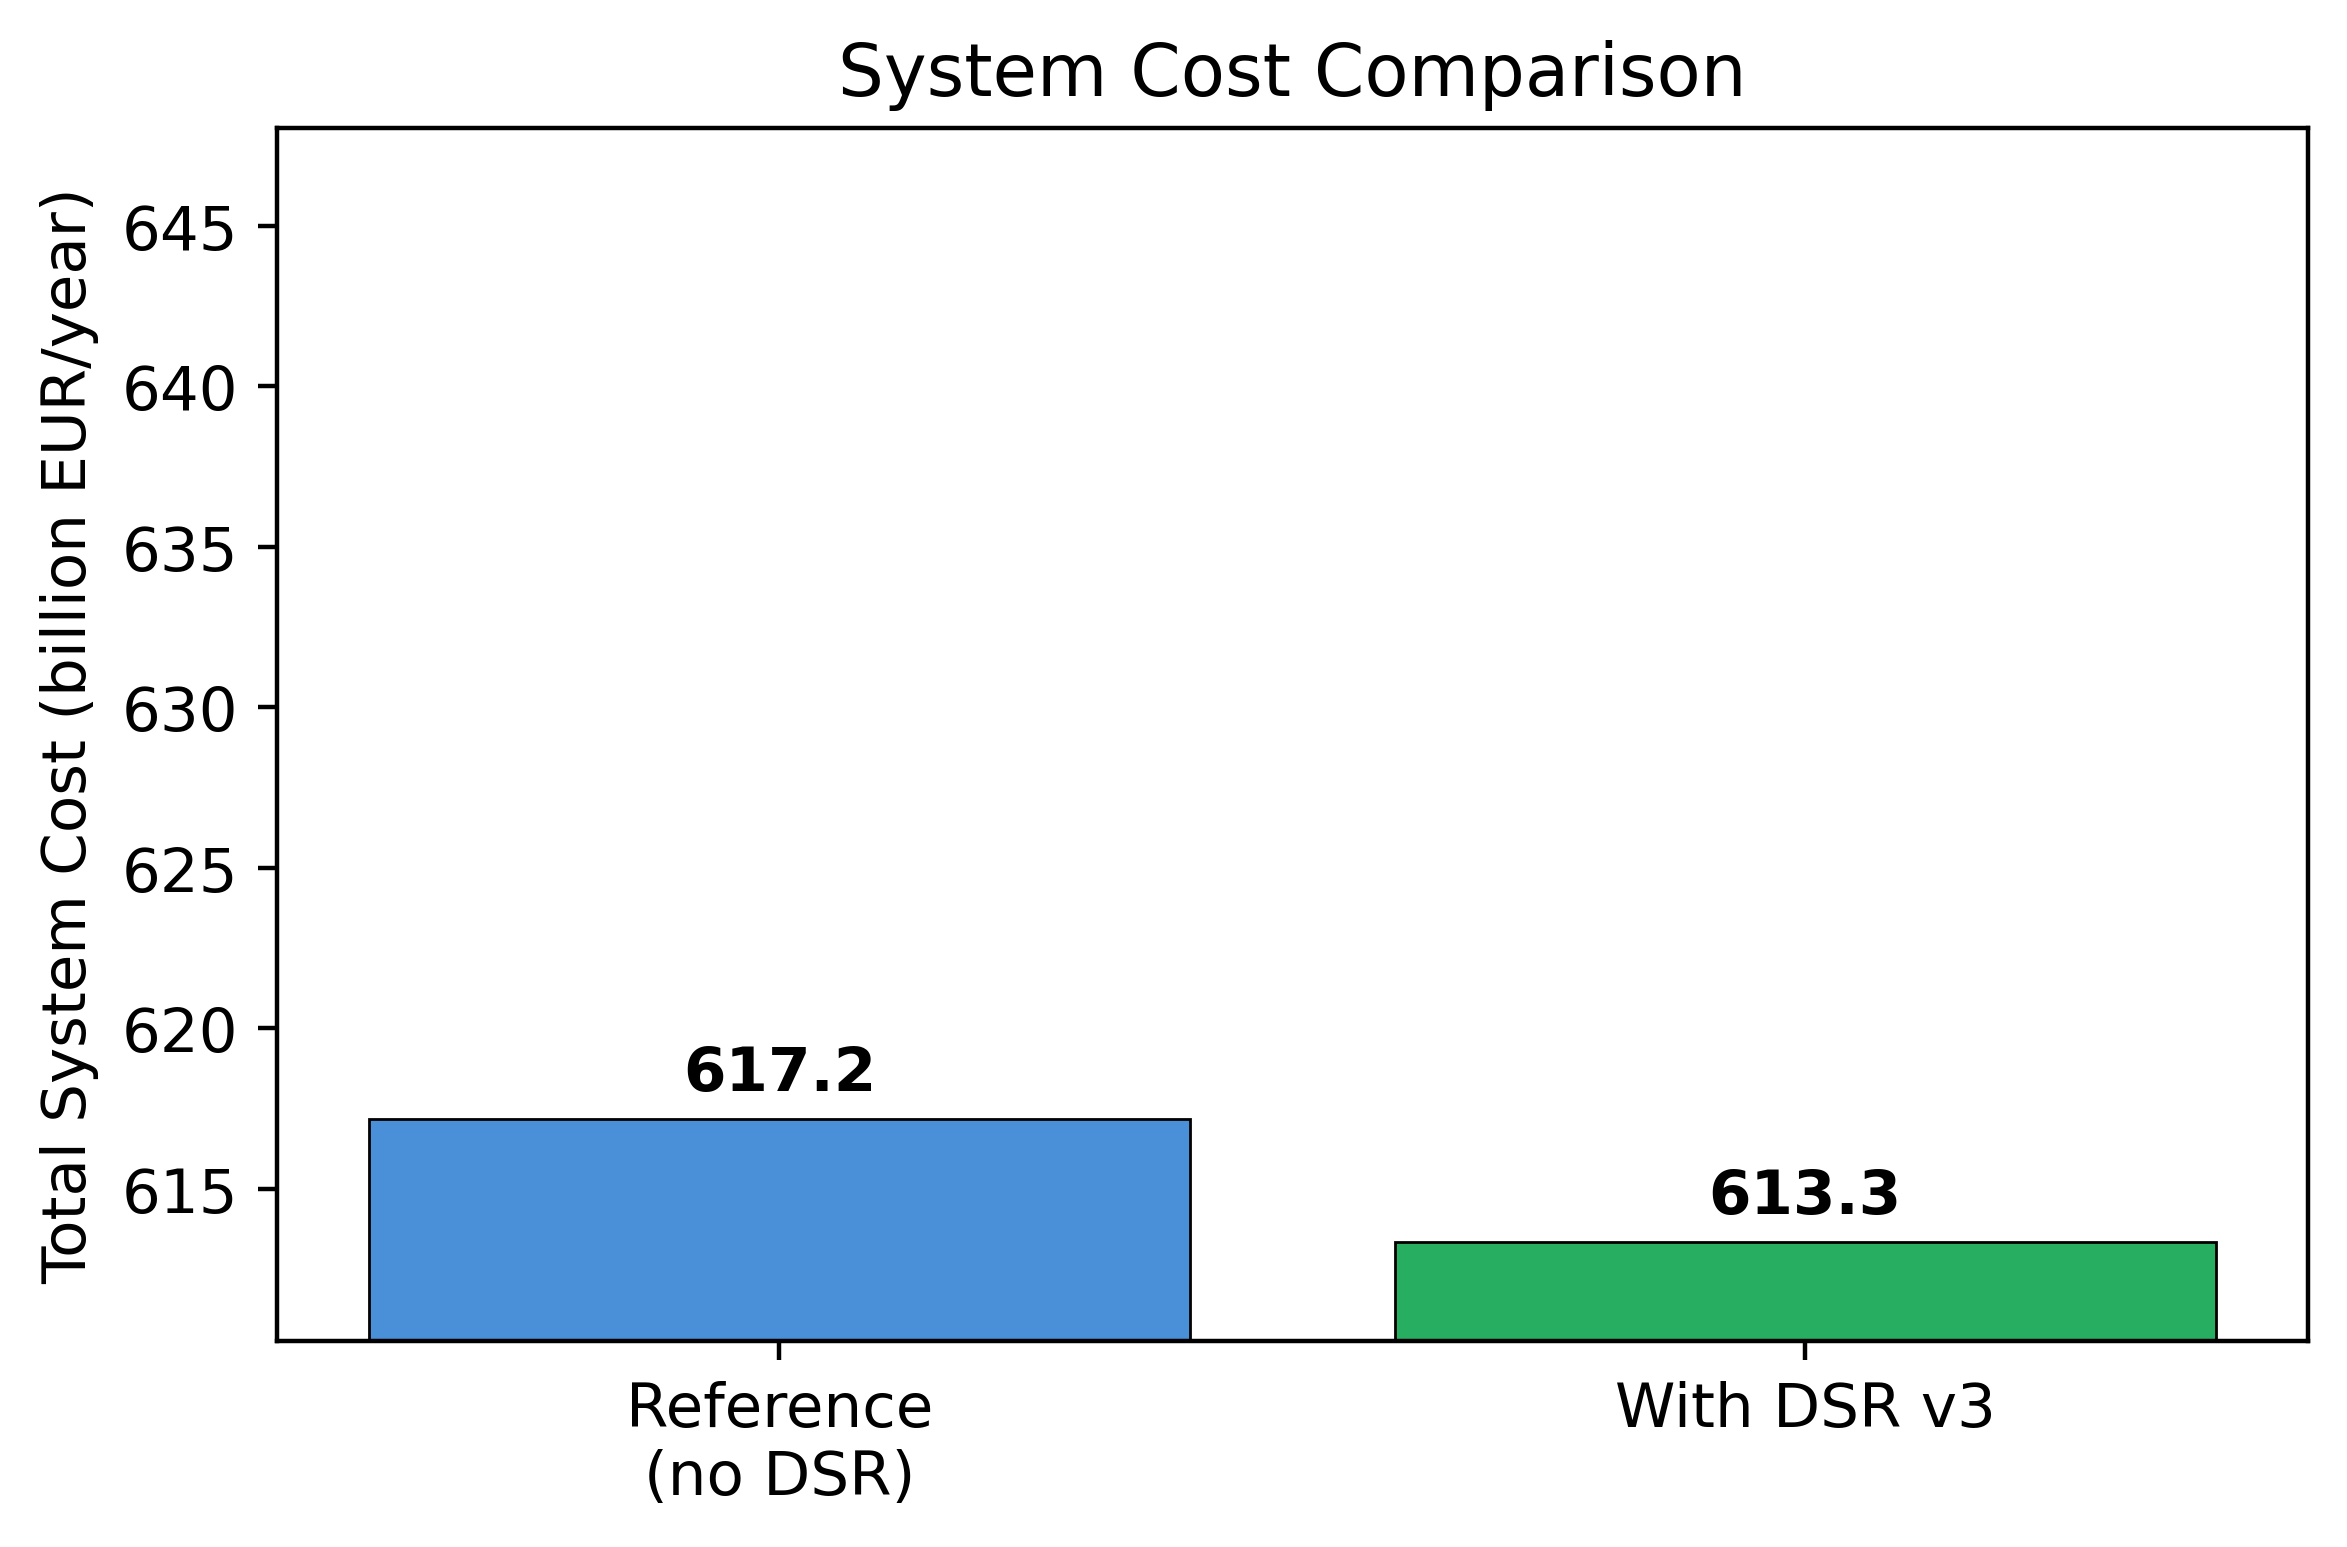

In [3]:
obj_ref = n_ref.objective
obj_dsr = n_dsr.objective
diff = obj_dsr - obj_ref
diff_pct = diff / obj_ref * 100

print(f'Reference (no DSR): {obj_ref/1e9:.2f} billion EUR')
print(f'DSR v3:             {obj_dsr/1e9:.2f} billion EUR')
print(f'DSR impact:         {diff/1e9:+.2f} billion EUR ({diff_pct:+.2f}%)')

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['Reference\n(no DSR)', 'With DSR v3'], [obj_ref/1e9, obj_dsr/1e9],
              color=['#4a90d9', '#27ae60'], edgecolor='black', linewidth=0.5)
ax.set_ylabel('Total System Cost (billion EUR/year)')
ax.set_title('System Cost Comparison')
for bar, val in zip(bars, [obj_ref/1e9, obj_dsr/1e9]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}', ha='center', va='bottom', fontweight='bold')
ax.set_ylim(bottom=min(obj_ref, obj_dsr)/1e9 * 0.995)
plt.tight_layout()
plt.show()

## 2. Electricity Prices

Average LV price (Reference): 112.12 EUR/MWh
Average LV price (DSR v3):    111.52 EUR/MWh
DSR impact: -0.53%


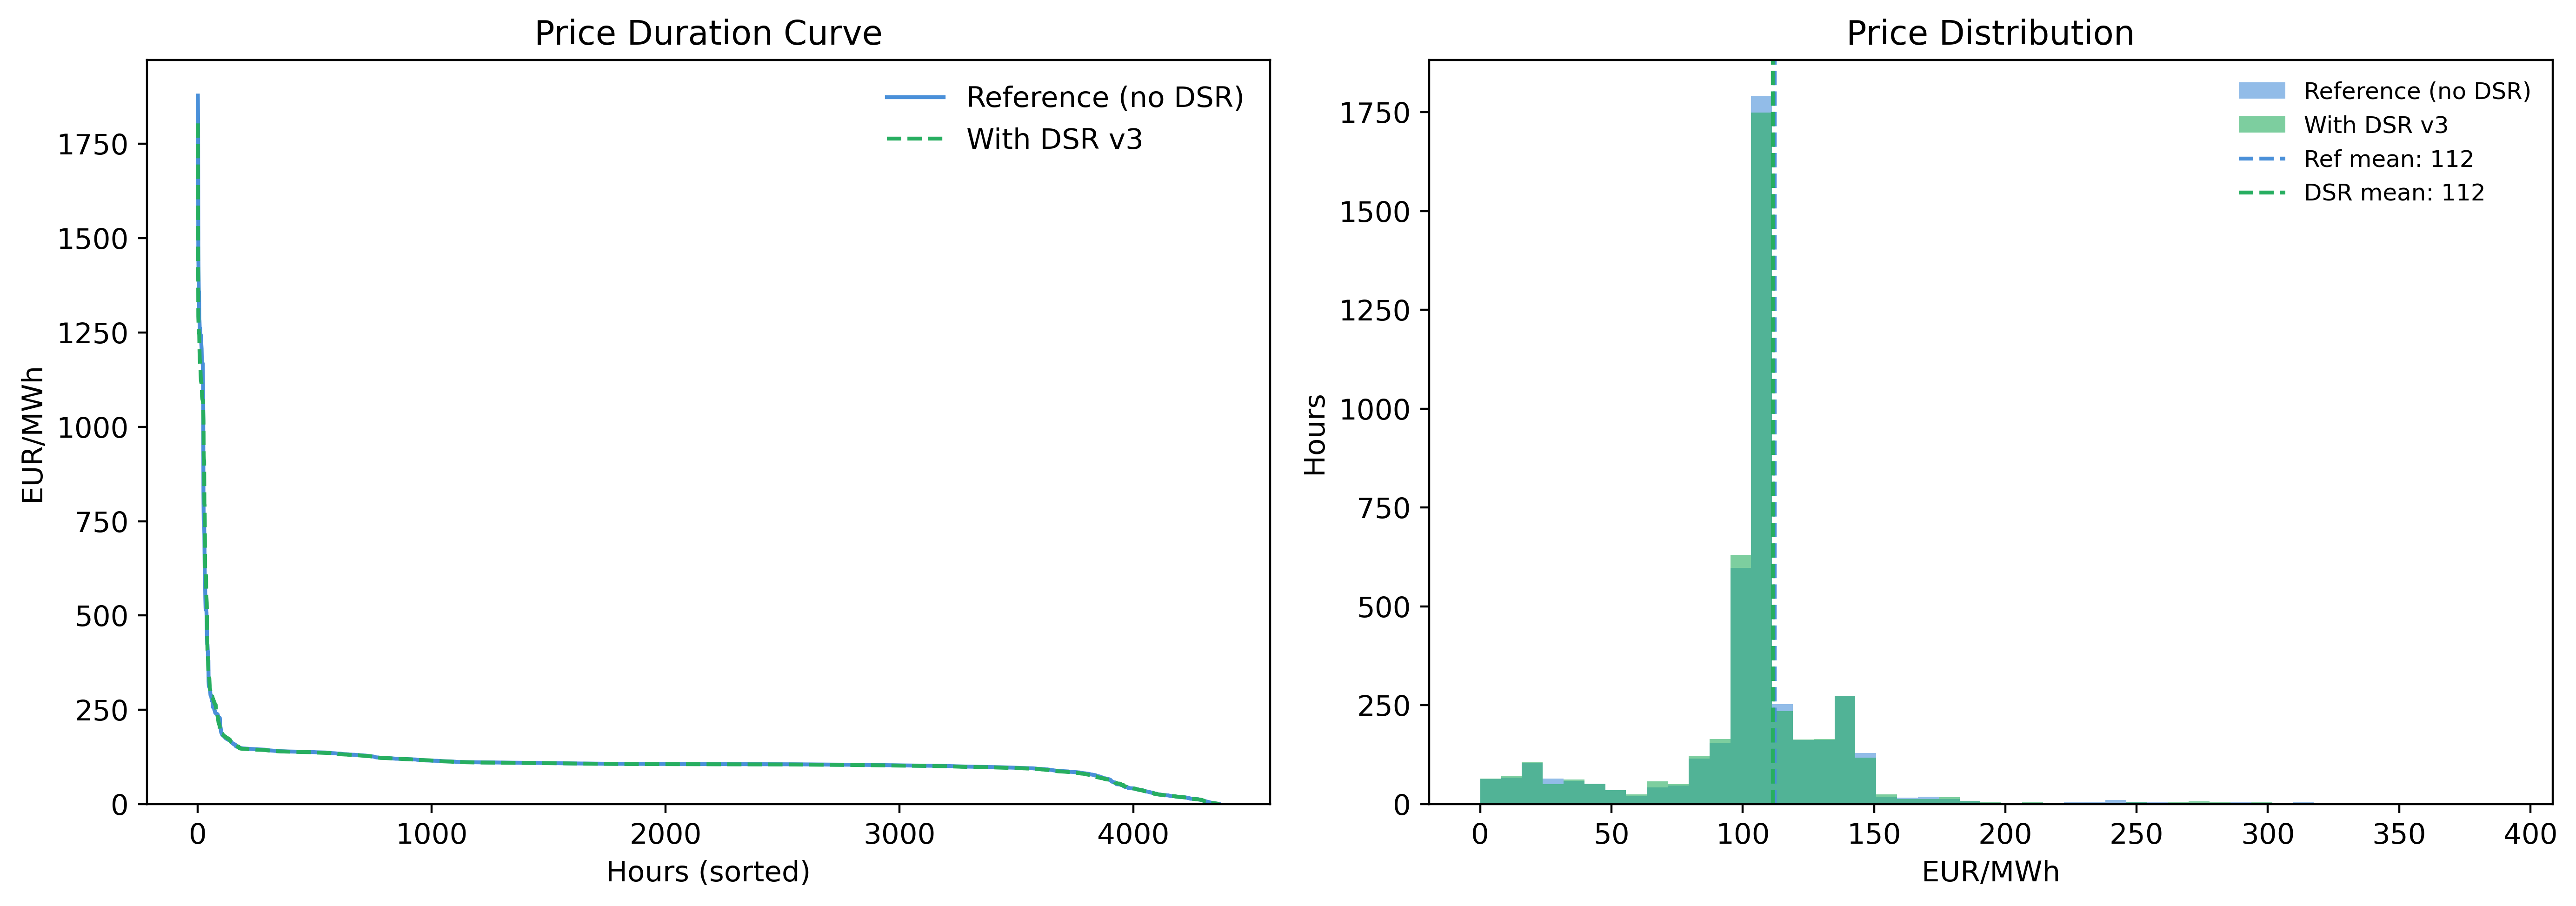

In [4]:
# Get low voltage bus prices
lv_ref = [b for b in n_ref.buses.index if 'low voltage' in b]
lv_dsr = [b for b in n_dsr.buses.index if 'low voltage' in b]

prices_ref = n_ref.buses_t.marginal_price[lv_ref]
prices_dsr = n_dsr.buses_t.marginal_price[lv_dsr]

avg_ref = prices_ref.mean().mean()
avg_dsr = prices_dsr.mean().mean()
print(f'Average LV price (Reference): {avg_ref:.2f} EUR/MWh')
print(f'Average LV price (DSR v3):    {avg_dsr:.2f} EUR/MWh')
print(f'DSR impact: {(avg_dsr-avg_ref)/avg_ref*100:+.2f}%')

# System-wide hourly average price
hourly_ref = prices_ref.mean(axis=1)
hourly_dsr = prices_dsr.mean(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Price duration curve
ax = axes[0]
sorted_ref = hourly_ref.sort_values(ascending=False).reset_index(drop=True)
sorted_dsr = hourly_dsr.sort_values(ascending=False).reset_index(drop=True)
ax.plot(sorted_ref.values, label='Reference (no DSR)', color='#4a90d9', linewidth=1.5)
ax.plot(sorted_dsr.values, label='With DSR v3', color='#27ae60', linewidth=1.5, linestyle='--')
ax.set_xlabel('Hours (sorted)')
ax.set_ylabel('EUR/MWh')
ax.set_title('Price Duration Curve')
ax.legend()
ax.set_ylim(bottom=0)

# Price histogram
ax = axes[1]
bins = np.linspace(0, max(hourly_ref.quantile(0.99), hourly_dsr.quantile(0.99)), 50)
ax.hist(hourly_ref, bins=bins, alpha=0.6, label='Reference (no DSR)', color='#4a90d9')
ax.hist(hourly_dsr, bins=bins, alpha=0.6, label='With DSR v3', color='#27ae60')
ax.axvline(avg_ref, color='#4a90d9', linestyle='--', linewidth=1.5, label=f'Ref mean: {avg_ref:.0f}')
ax.axvline(avg_dsr, color='#27ae60', linestyle='--', linewidth=1.5, label=f'DSR mean: {avg_dsr:.0f}')
ax.set_xlabel('EUR/MWh')
ax.set_ylabel('Hours')
ax.set_title('Price Distribution')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

## 3. Renewable Curtailment

Reference: Curtailed 1.02 TWh (0.23%)
DSR v3: Curtailed 0.75 TWh (0.17%)

DSR reduces curtailment by 27%


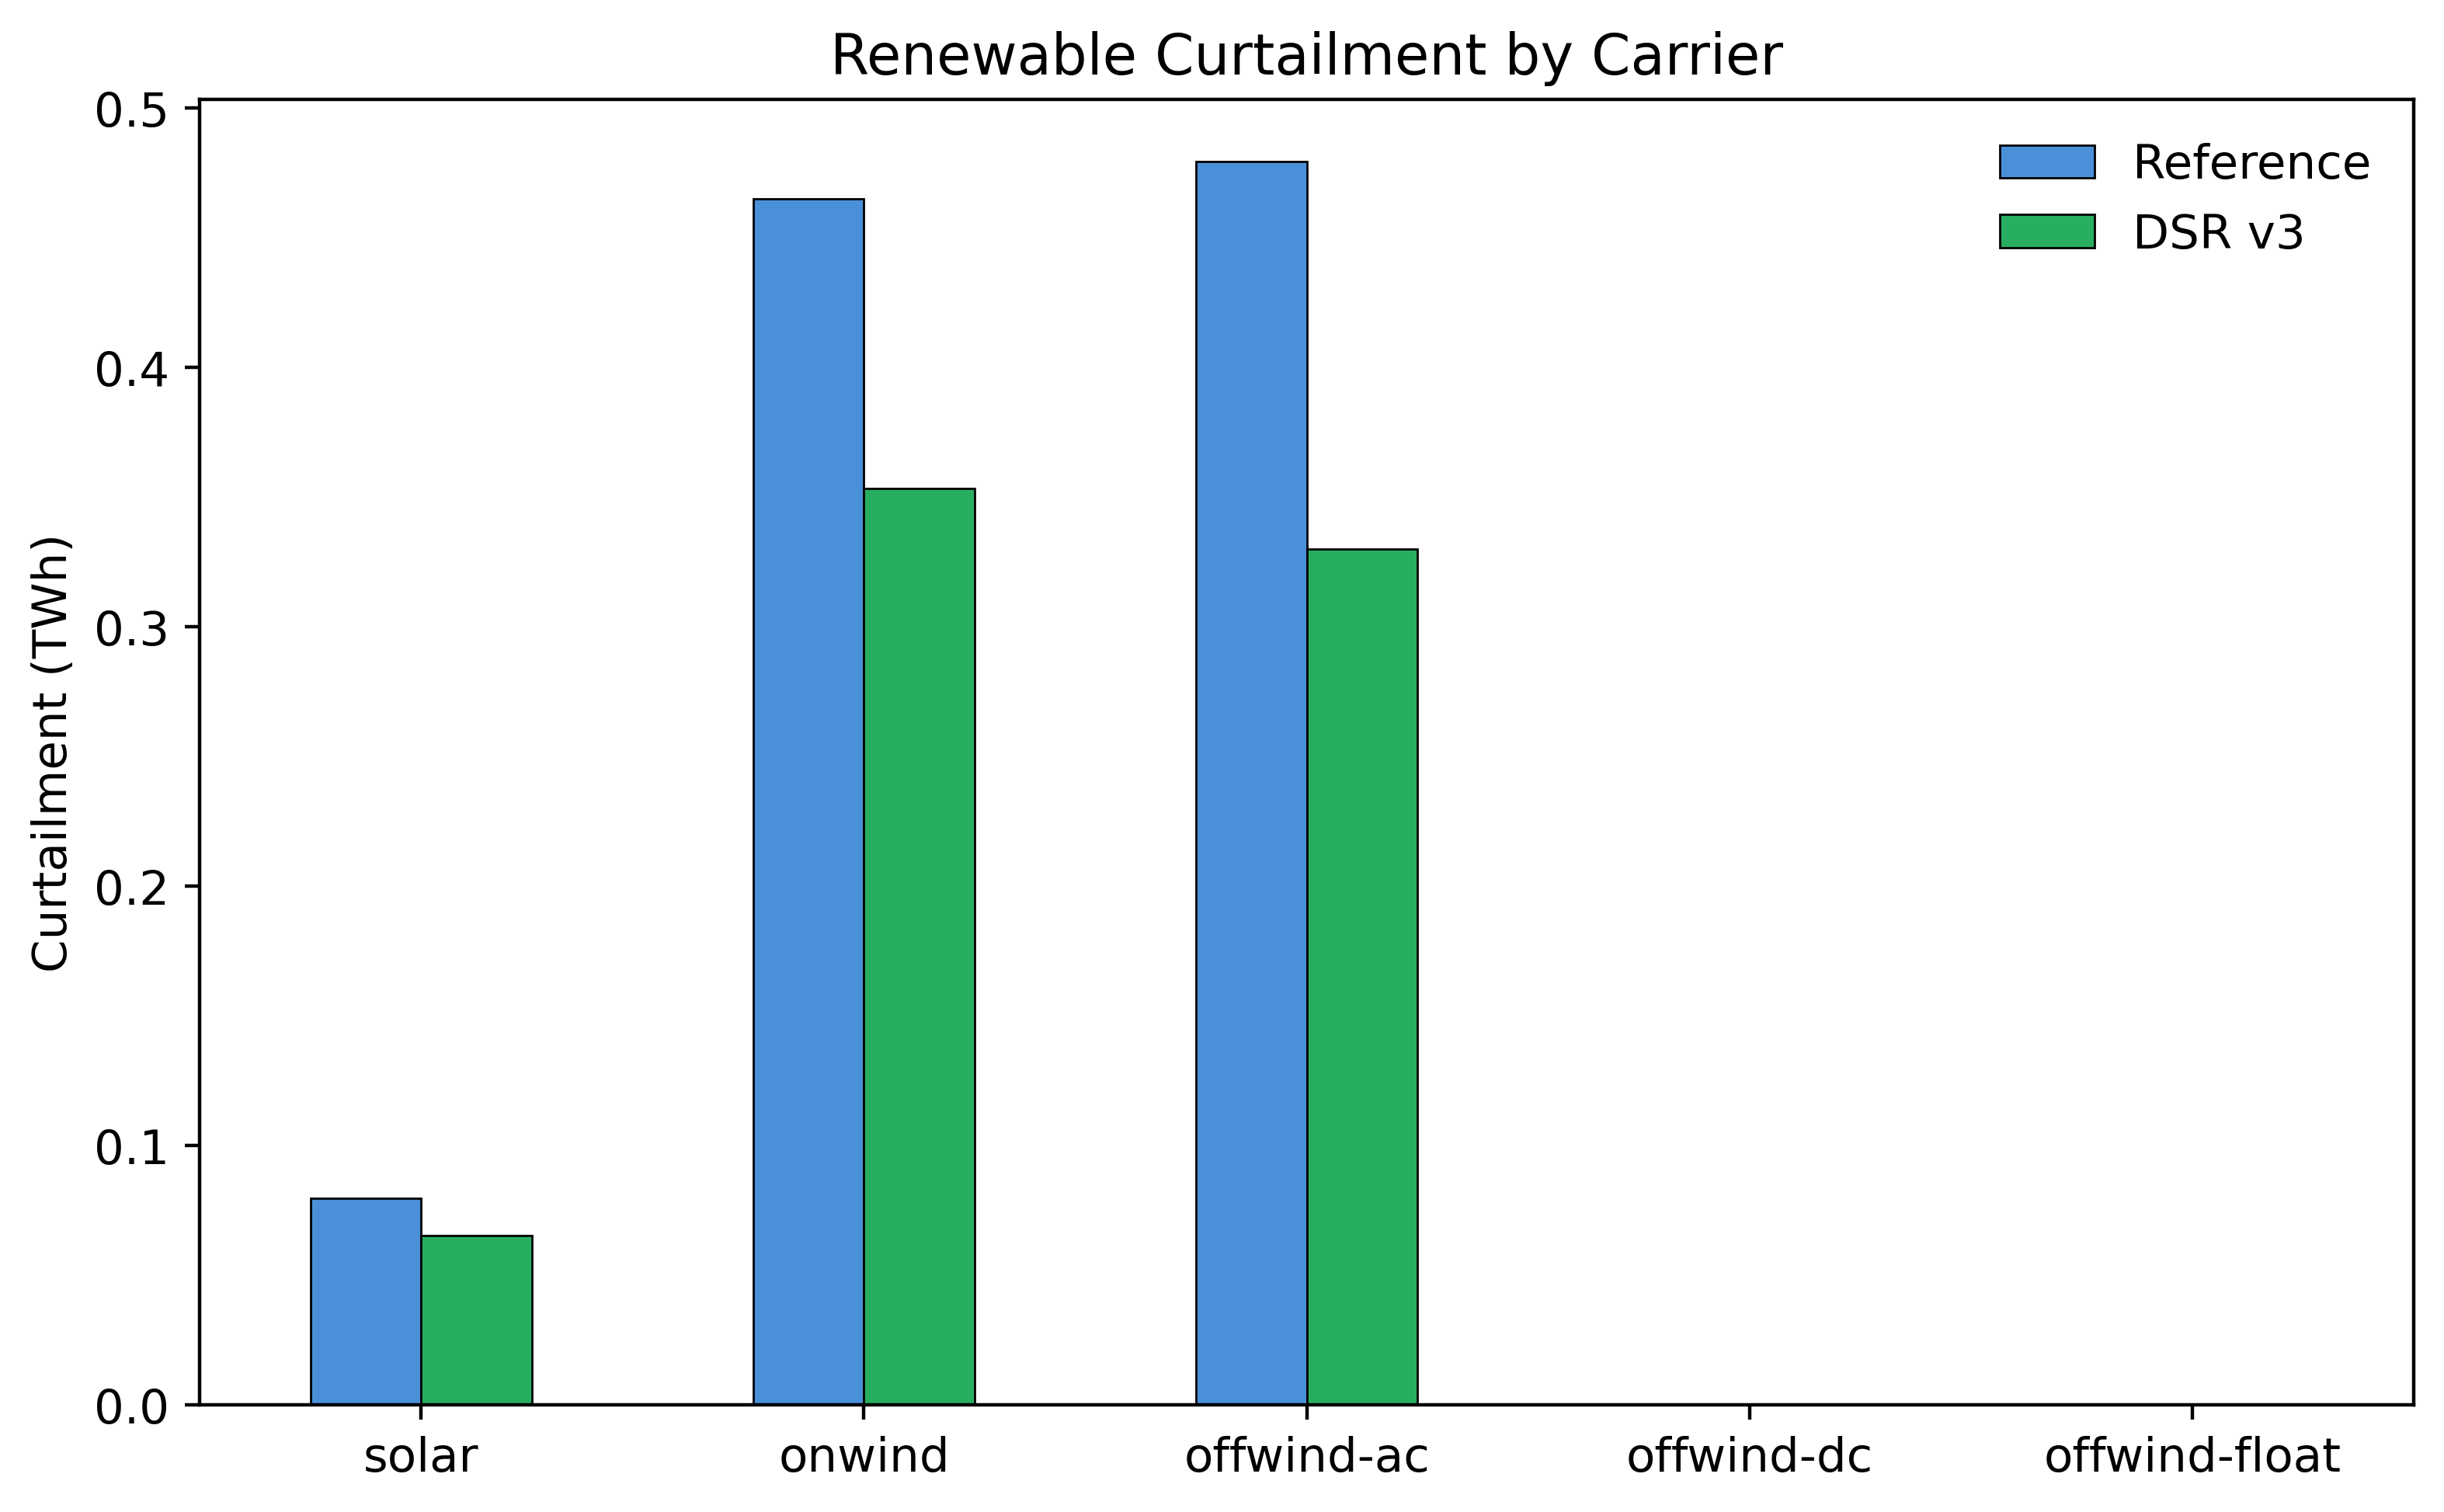

In [5]:
re_carriers = ['solar', 'onwind', 'offwind-ac', 'offwind-dc', 'offwind-float']

results = {}
for label, n_ in [('Reference', n_ref), ('DSR v3', n_dsr)]:
    re = n_.generators[n_.generators.carrier.isin(re_carriers)]
    potential = (n_.generators_t.p_max_pu[re.index] * re.p_nom_opt).sum().sum()
    actual = n_.generators_t.p[re.index].sum().sum()
    curtailed = potential - actual
    results[label] = {'potential': potential/1e6, 'actual': actual/1e6, 'curtailed': curtailed/1e6,
                      'pct': curtailed/potential*100}
    print(f'{label}: Curtailed {curtailed/1e6:.2f} TWh ({curtailed/potential*100:.2f}%)')

curt_reduction = (results['DSR v3']['curtailed'] - results['Reference']['curtailed']) / results['Reference']['curtailed'] * 100
print(f'\nDSR reduces curtailment by {-curt_reduction:.0f}%')

# Curtailment by carrier
fig, ax = plt.subplots(figsize=(8, 5))
carrier_curt = {}
for label, n_ in [('Reference', n_ref), ('DSR v3', n_dsr)]:
    re = n_.generators[n_.generators.carrier.isin(re_carriers)]
    for c in re_carriers:
        gens_c = re[re.carrier == c]
        if gens_c.empty:
            continue
        pot = (n_.generators_t.p_max_pu[gens_c.index] * gens_c.p_nom_opt).sum().sum()
        act = n_.generators_t.p[gens_c.index].sum().sum()
        carrier_curt.setdefault(c, {})[label] = (pot - act) / 1e6

df_curt = pd.DataFrame(carrier_curt).T
df_curt.plot(kind='bar', ax=ax, color=['#4a90d9', '#27ae60'], edgecolor='black', linewidth=0.5)
ax.set_ylabel('Curtailment (TWh)')
ax.set_title('Renewable Curtailment by Carrier')
ax.legend()
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 4. DSR Store Utilization

Total DSR stores: 340
Stores with capacity built: 302
Total capacity available: 63617 MWh
Total capacity built: 60668 MWh (95.4%)
Capital cost: 5.0 EUR/MWh/year
Total DSR investment: 0.30 M EUR/year


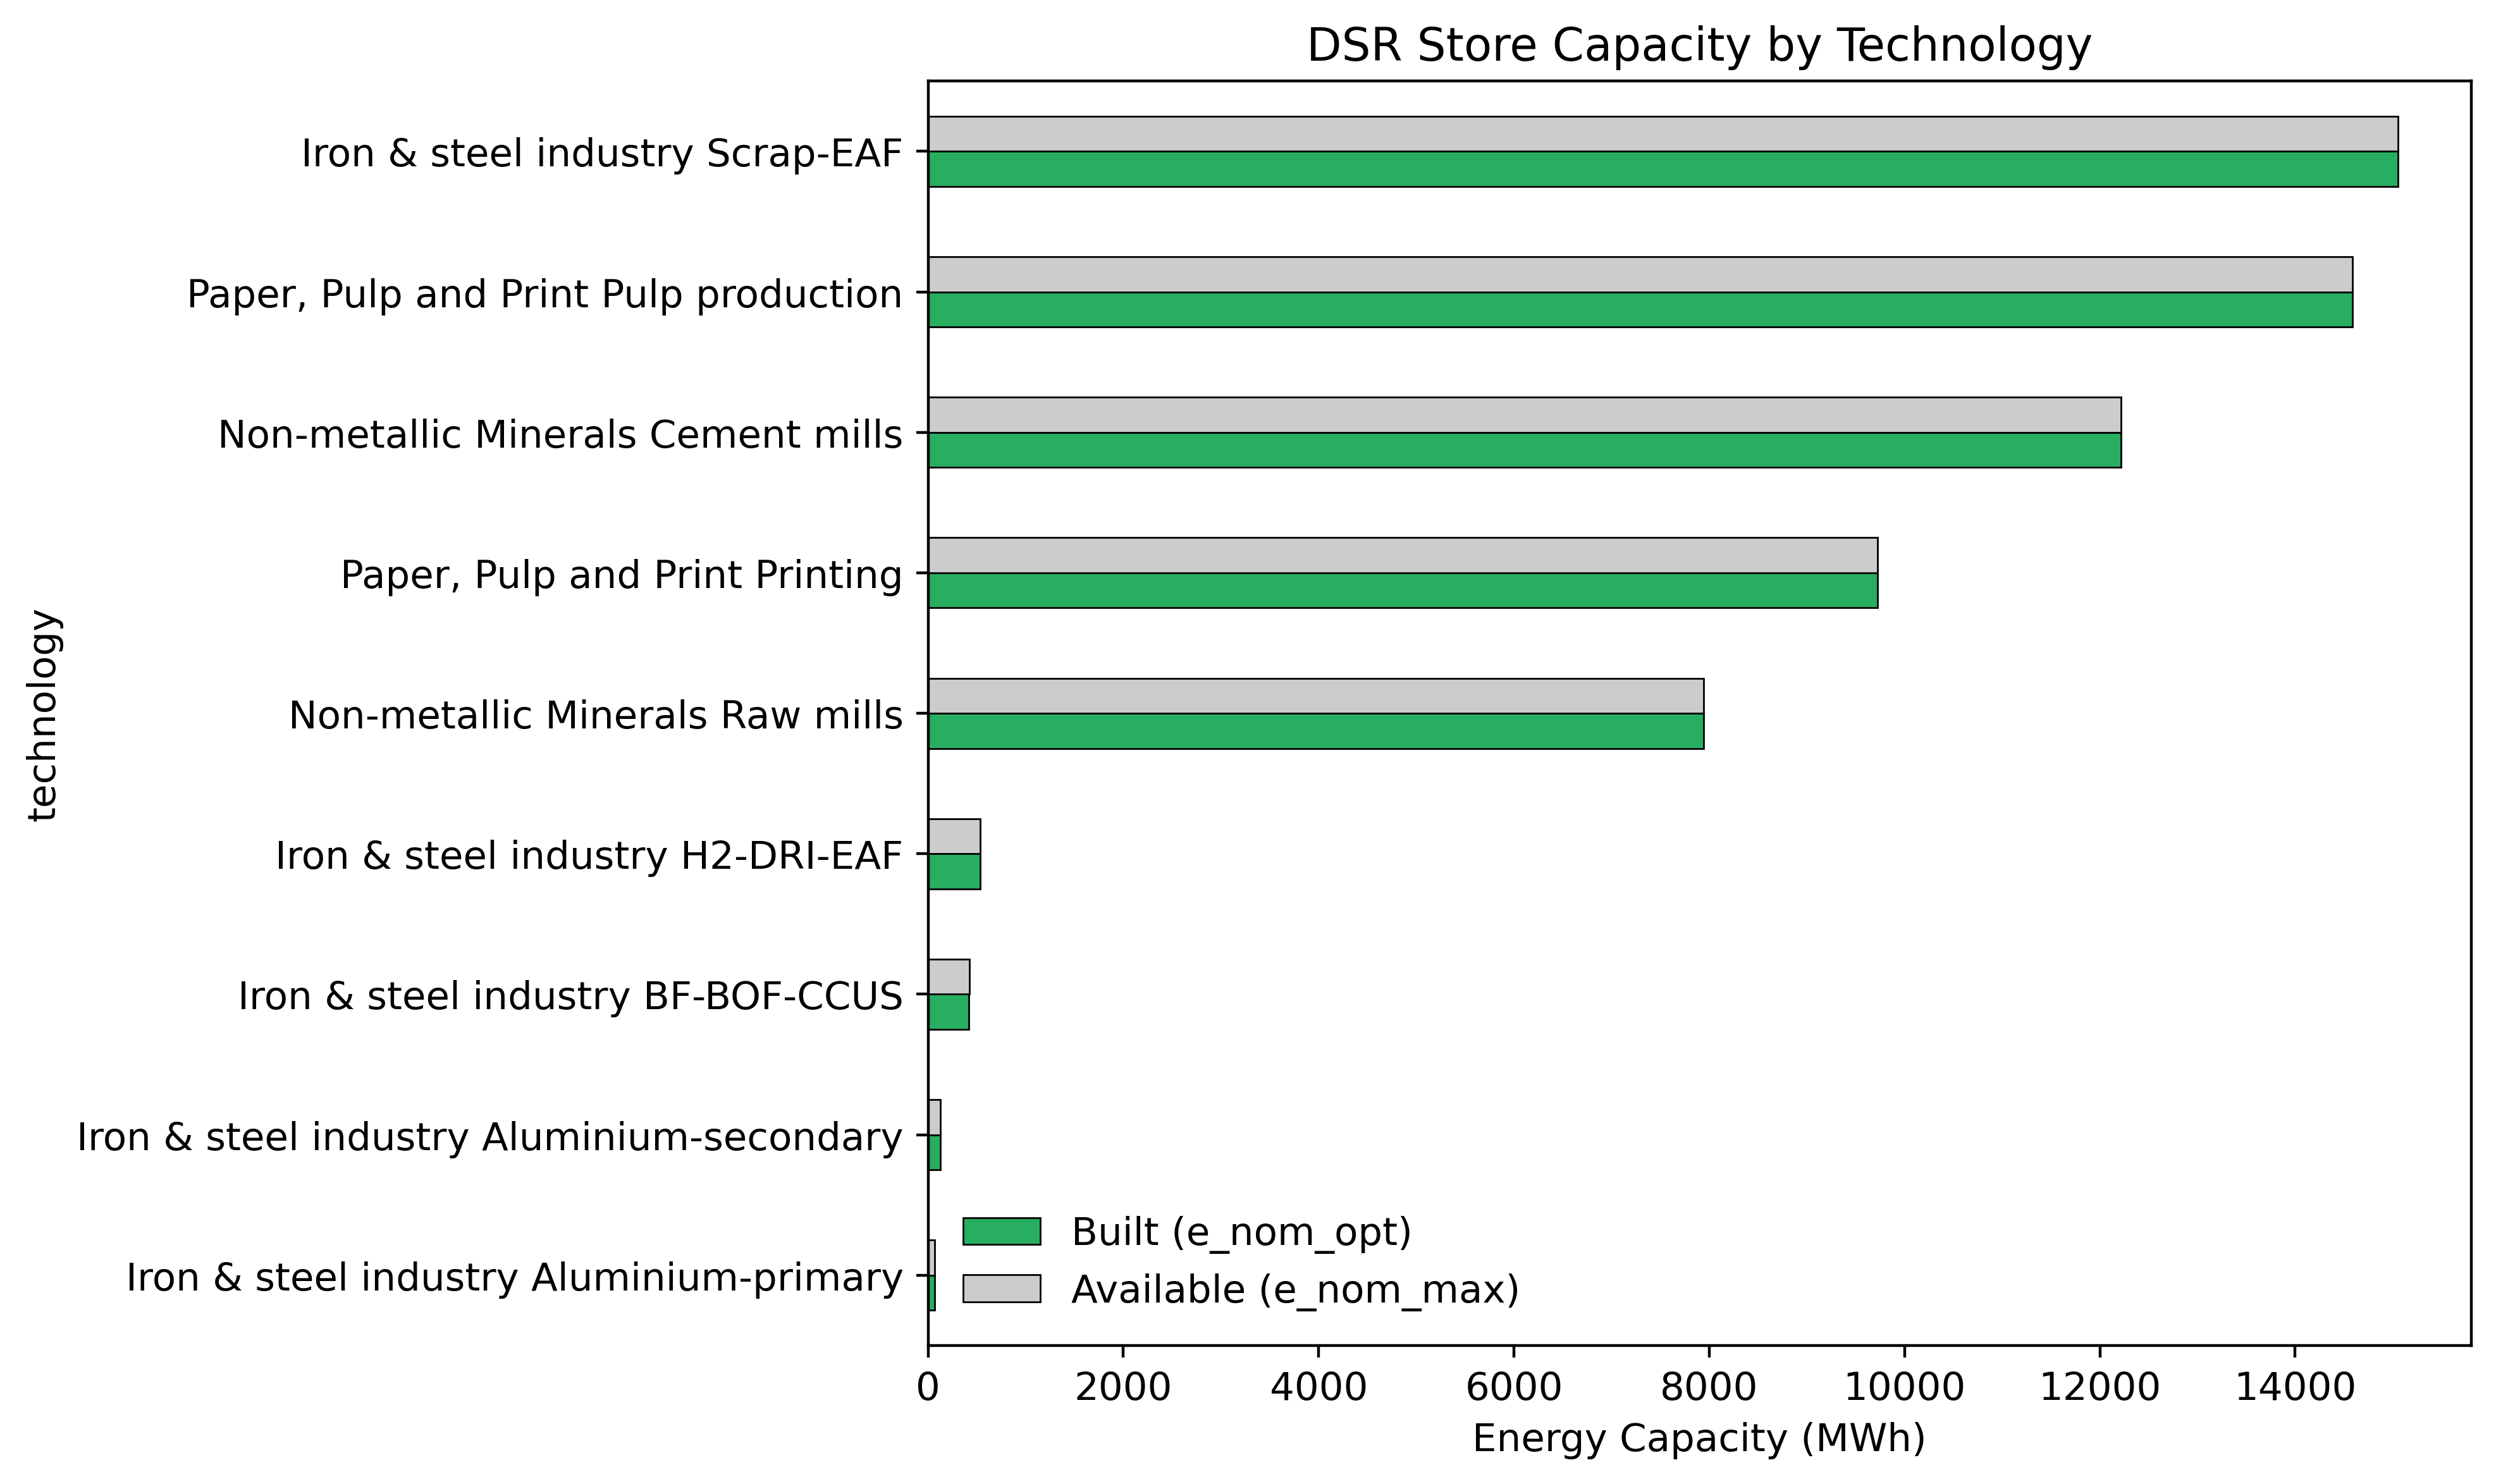

In [6]:
dsr_stores = n_dsr.stores[n_dsr.stores.carrier == 'industry dsr']

print(f'Total DSR stores: {len(dsr_stores)}')
print(f'Stores with capacity built: {(dsr_stores.e_nom_opt > 0).sum()}')
print(f'Total capacity available: {dsr_stores.e_nom_max.sum():.0f} MWh')
print(f'Total capacity built: {dsr_stores.e_nom_opt.sum():.0f} MWh ({dsr_stores.e_nom_opt.sum()/dsr_stores.e_nom_max.sum()*100:.1f}%)')
print(f'Capital cost: {dsr_stores.capital_cost.iloc[0]:.1f} EUR/MWh/year')
print(f'Total DSR investment: {(dsr_stores.e_nom_opt * dsr_stores.capital_cost).sum()/1e6:.2f} M EUR/year')

# Store capacity by technology
dsr_stores_built = dsr_stores[dsr_stores.e_nom_opt > 0].copy()
dsr_stores_built['technology'] = dsr_stores_built.index.map(
    lambda x: x.split(' industry dsr ')[-1] if ' industry dsr ' in x else 'unknown'
)

tech_cap = dsr_stores_built.groupby('technology')[['e_nom_opt', 'e_nom_max']].sum()
tech_cap = tech_cap.sort_values('e_nom_opt', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
tech_cap.plot(kind='barh', ax=ax, color=['#27ae60', '#cccccc'], edgecolor='black', linewidth=0.5)
ax.set_xlabel('Energy Capacity (MWh)')
ax.set_title('DSR Store Capacity by Technology')
ax.legend(['Built (e_nom_opt)', 'Available (e_nom_max)'])
plt.tight_layout()
plt.show()

## 5. DSR Dispatch Profile

Total energy charged (increased demand): 10.32 TWh
Total energy discharged (reduced demand): 10.11 TWh
Efficiency loss: 0.21 TWh
Peak charge power: 14.5 GW
Peak discharge power: 13.7 GW


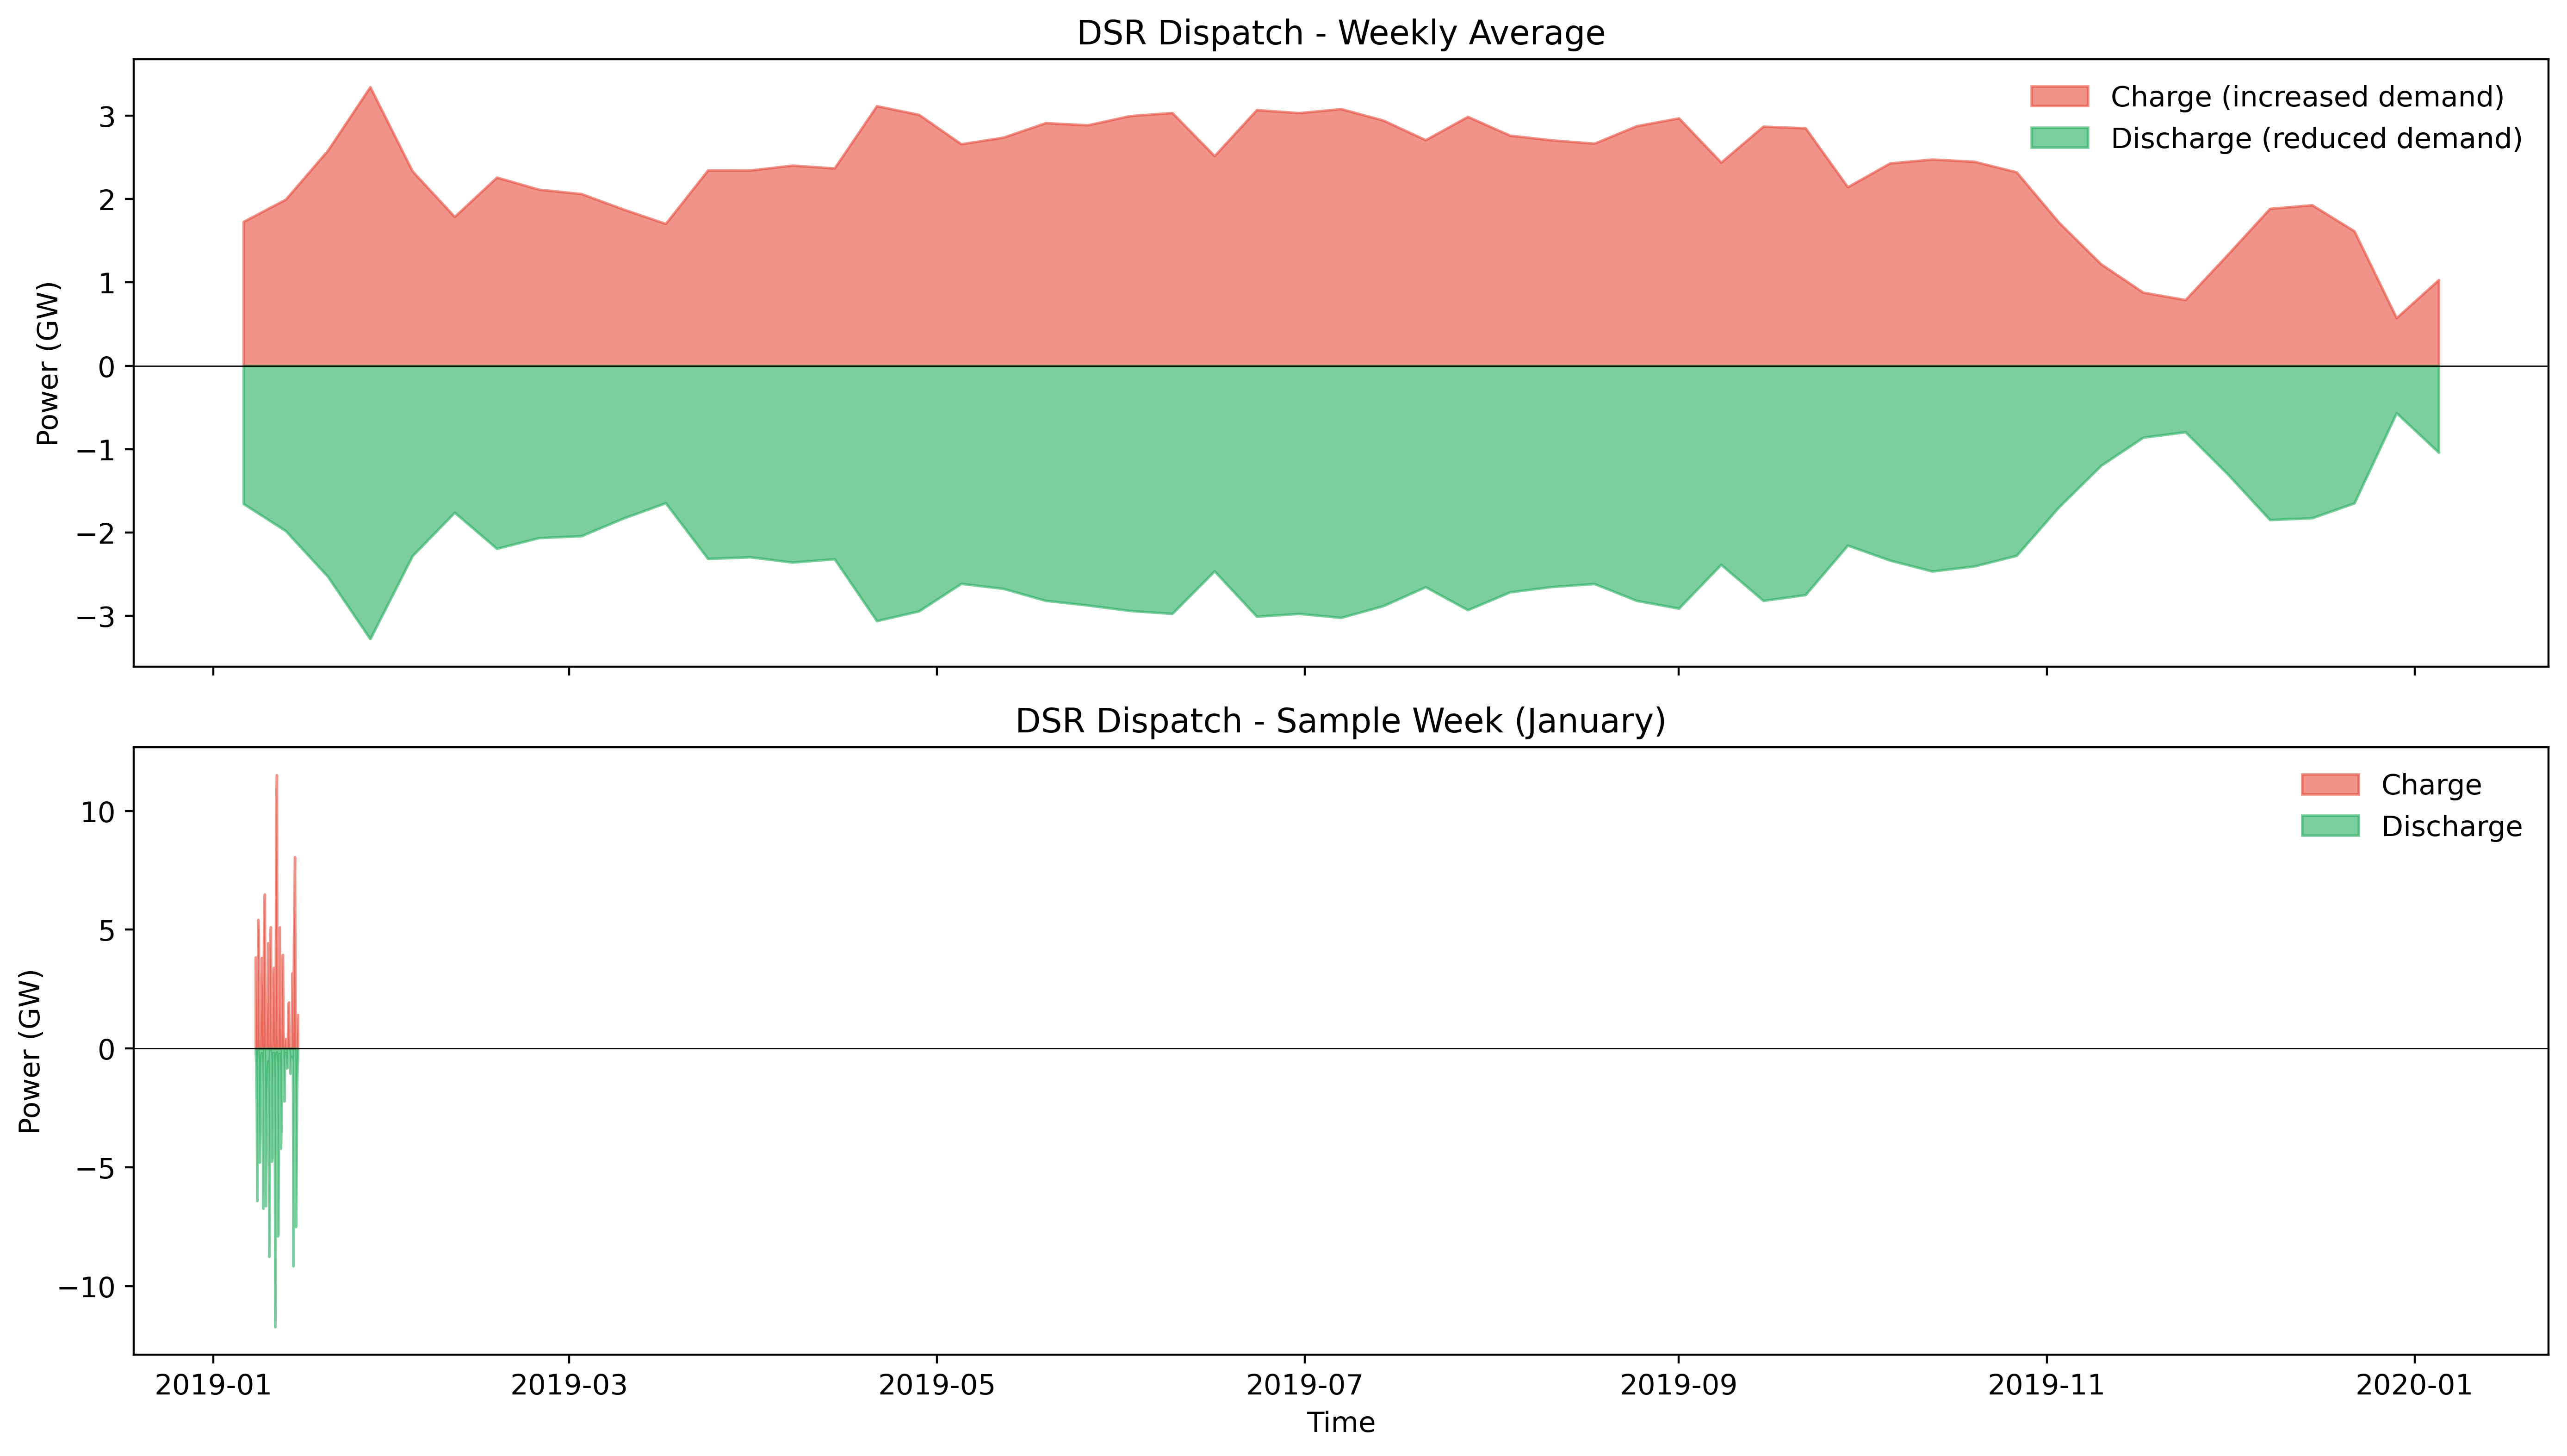

In [7]:
# Charge and discharge link flows
ch_links = n_dsr.links[n_dsr.links.carrier == 'industry dsr charge']
dch_links = n_dsr.links[n_dsr.links.carrier == 'industry dsr discharge']

charge_total = n_dsr.links_t.p0[ch_links.index].sum(axis=1)
discharge_total = n_dsr.links_t.p0[dch_links.index].sum(axis=1)
net_dsr = charge_total - discharge_total  # positive = extra demand, negative = reduced demand

print(f'Total energy charged (increased demand): {charge_total.sum()/1e6:.2f} TWh')
print(f'Total energy discharged (reduced demand): {discharge_total.sum()/1e6:.2f} TWh')
print(f'Efficiency loss: {(charge_total.sum()-discharge_total.sum())/1e6:.2f} TWh')
print(f'Peak charge power: {charge_total.max()/1e3:.1f} GW')
print(f'Peak discharge power: {discharge_total.max()/1e3:.1f} GW')

# --- PLOT 1: Net DSR position over the year (daily average) ---
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

ax = axes[0]
daily_net = net_dsr.resample('D').mean() / 1e3  # GW
colors_net = ['#e74c3c' if v > 0 else '#27ae60' for v in daily_net.values]
ax.bar(daily_net.index, daily_net.values, color=colors_net, alpha=0.7, width=1.0)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Net DSR (GW)')
ax.set_title('Daily Average Net DSR Position (red = charging/extra demand, green = discharging/reduced demand)')
ax.set_xlim(daily_net.index[0], daily_net.index[-1])

# --- PLOT 2: Sample week with hourly dispatch ---
ax = axes[1]
jan_start = charge_total.index[0] + pd.Timedelta(days=7)
jan_end = jan_start + pd.Timedelta(days=7)
ch_week = charge_total[jan_start:jan_end]
dch_week = discharge_total[jan_start:jan_end]
ax.fill_between(ch_week.index, 0, ch_week.values/1e3, alpha=0.6, color='#e74c3c', label='Charge (extra demand)')
ax.fill_between(dch_week.index, 0, -dch_week.values/1e3, alpha=0.6, color='#27ae60', label='Discharge (reduced demand)')
ax.axhline(0, color='black', linewidth=0.5)
ax.set_ylabel('Power (GW)')
ax.set_xlabel('Time')
ax.set_title('DSR Dispatch - Sample Week (January, hourly)')
ax.legend()

plt.tight_layout()
plt.show()

### 5b. DSR Response to Price Signals

The core rationale of DSR: **charge (increase demand) when electricity is cheap, discharge (reduce demand) when expensive**. The plots below show this behavior on representative days.

In [ ]:
# Get system-wide average LV price from the DSR run
lv_buses_dsr = [b for b in n_dsr.buses.index if 'low voltage' in b]
price_hourly = n_dsr.buses_t.marginal_price[lv_buses_dsr].mean(axis=1)

# Find a "high-variability" day where DSR is most active (top net-DSR swing day)
daily_swing = net_dsr.groupby(net_dsr.index.date).apply(lambda x: x.max() - x.min())
best_day = pd.Timestamp(daily_swing.idxmax())

# Also pick a typical winter day and a summer day for comparison
winter_day = pd.Timestamp('2019-01-15')
summer_day = pd.Timestamp('2019-07-15')

days_to_plot = [
    (best_day, f'Highest DSR Activity Day ({best_day.strftime("%b %d")})', '#2c3e50'),
    (winter_day, 'Winter Day (Jan 15)', '#2980b9'),
    (summer_day, 'Summer Day (Jul 15)', '#e67e22'),
]

fig, axes = plt.subplots(len(days_to_plot), 1, figsize=(14, 4 * len(days_to_plot)))

for idx, (day, title, color) in enumerate(days_to_plot):
    ax1 = axes[idx]
    day_end = day + pd.Timedelta(days=1)
    
    # Price on left axis
    price_day = price_hourly[day:day_end]
    ax1.plot(price_day.index, price_day.values, color=color, linewidth=2, label='Avg. LV Price')
    ax1.set_ylabel('Price (EUR/MWh)', color=color)
    ax1.tick_params(axis='y', labelcolor=color)
    
    # Net DSR on right axis
    ax2 = ax1.twinx()
    net_day = net_dsr[day:day_end]
    net_colors = ['#e74c3c' if v > 0 else '#27ae60' for v in net_day.values]
    ax2.bar(net_day.index, net_day.values / 1e3, color=net_colors, alpha=0.5, width=0.06, label='Net DSR')
    ax2.set_ylabel('Net DSR (GW)\nred=charge, green=discharge')
    ax2.axhline(0, color='grey', linewidth=0.5, linestyle='--')
    
    ax1.set_title(title)
    
    # Combined legend
    lines1, labels1 = ax1.get_legend_handles_labels()
    from matplotlib.patches import Patch
    charge_patch = Patch(facecolor='#e74c3c', alpha=0.5, label='DSR Charge (extra demand)')
    discharge_patch = Patch(facecolor='#27ae60', alpha=0.5, label='DSR Discharge (reduced demand)')
    ax1.legend(handles=lines1 + [charge_patch, discharge_patch], loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

print('\nExpected behavior: DSR charges (red bars) during LOW price hours')
print('and discharges (green bars) during HIGH price hours.')

In [ ]:
# Average DSR behavior by hour of day (across entire year) vs average price
avg_charge_by_hour = charge_total.groupby(charge_total.index.hour).mean() / 1e3
avg_discharge_by_hour = discharge_total.groupby(discharge_total.index.hour).mean() / 1e3
avg_price_by_hour = price_hourly.groupby(price_hourly.index.hour).mean()

fig, ax1 = plt.subplots(figsize=(12, 5))

# Stacked bars for charge/discharge
hours = avg_charge_by_hour.index
width = 0.35
ax1.bar(hours - width/2, avg_charge_by_hour.values, width, color='#e74c3c', alpha=0.7, label='Avg Charge (GW)')
ax1.bar(hours + width/2, avg_discharge_by_hour.values, width, color='#27ae60', alpha=0.7, label='Avg Discharge (GW)')
ax1.set_xlabel('Hour of Day')
ax1.set_ylabel('Average Power (GW)')
ax1.set_xticks(range(0, 24, 2))

# Price overlay on right axis
ax2 = ax1.twinx()
ax2.plot(hours, avg_price_by_hour.values, 'ko-', linewidth=2.5, markersize=5, label='Avg Price (EUR/MWh)')
ax2.set_ylabel('Price (EUR/MWh)')

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

ax1.set_title('Average DSR Dispatch vs Electricity Price by Hour of Day (full year)')
plt.tight_layout()
plt.show()

print('If DSR is rational: charge should be higher during low-price hours,')
print('discharge should be higher during high-price hours.')

## 6. Price Impact of DSR by Hour of Day

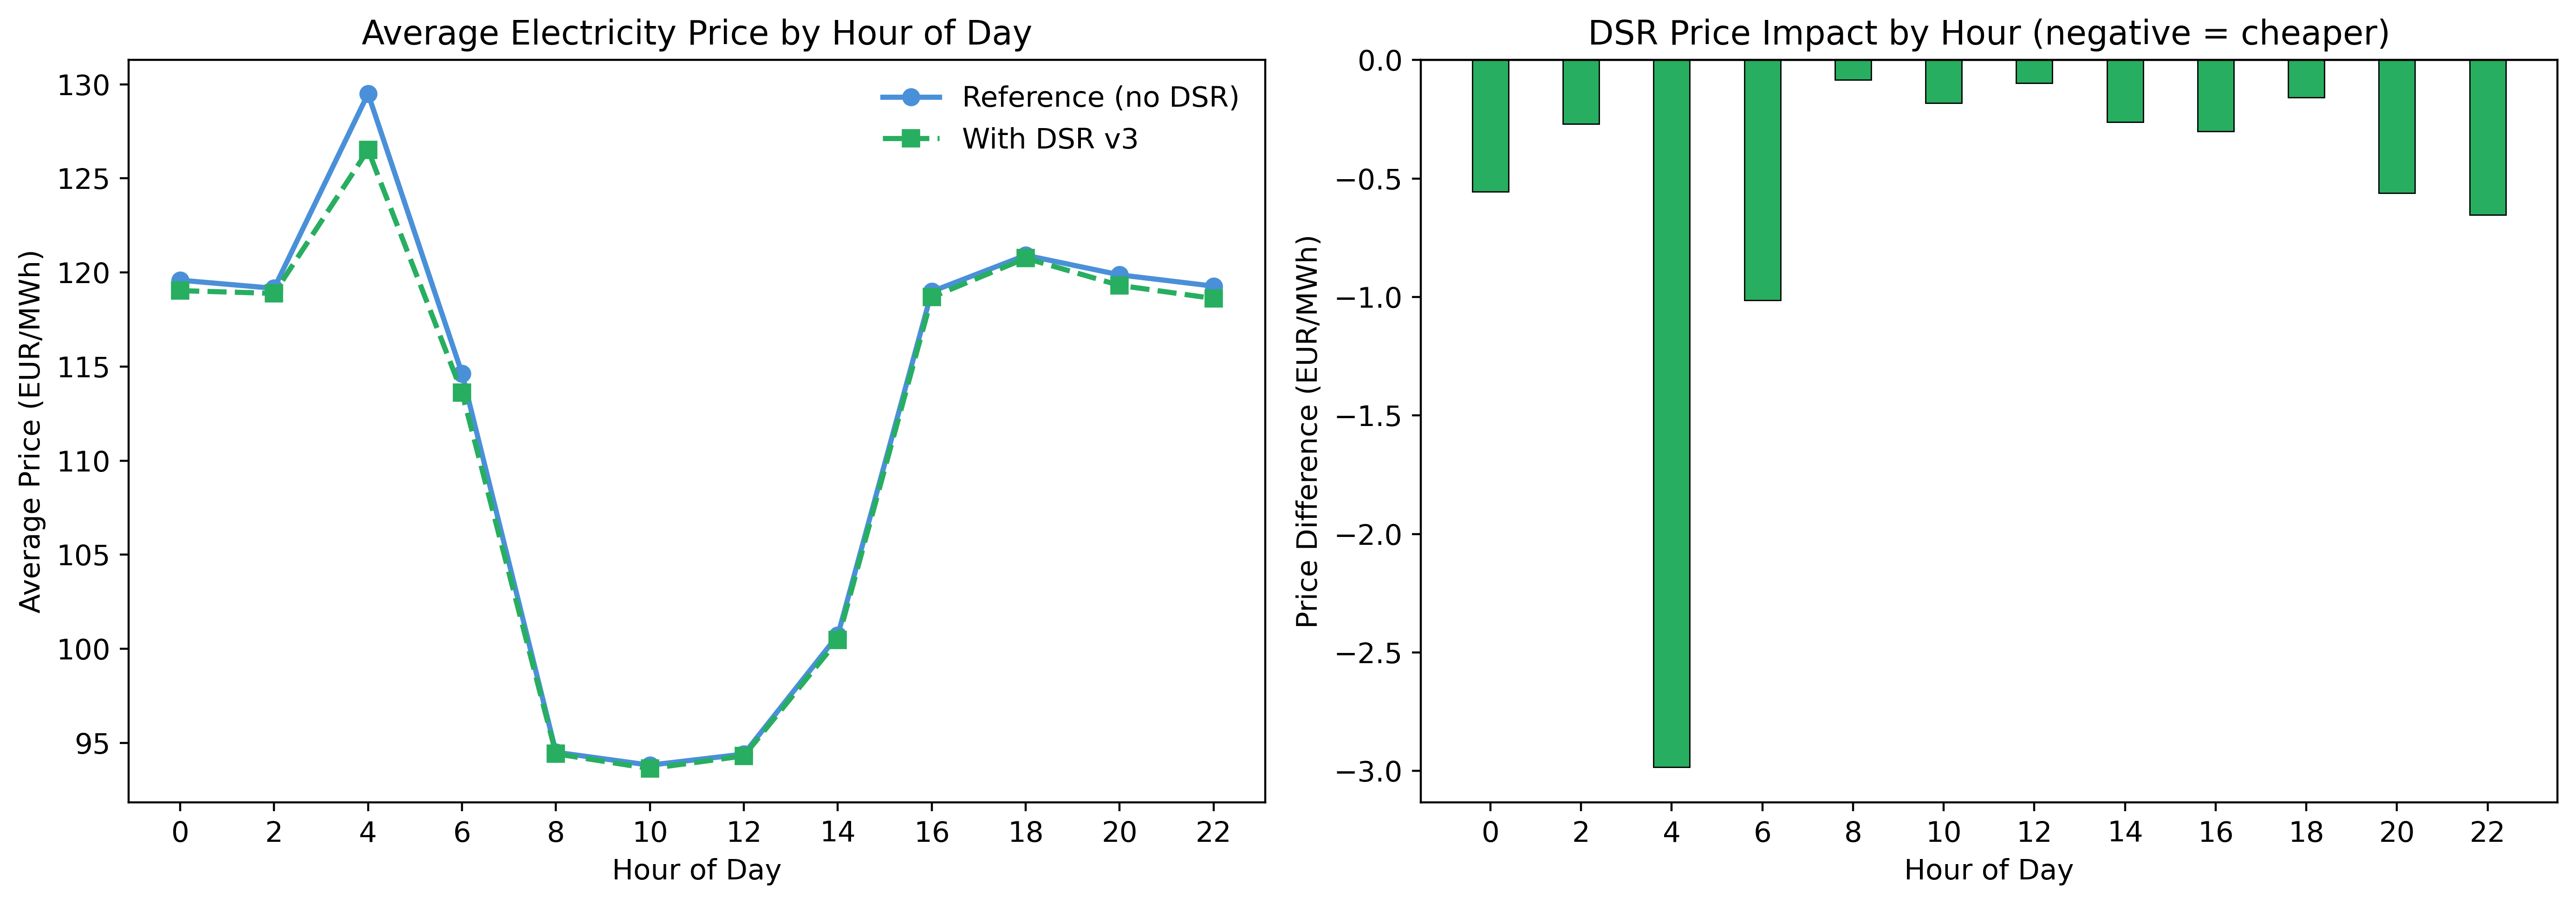

In [8]:
# Average price by hour of day
hourly_ref = prices_ref.mean(axis=1)
hourly_dsr_price = prices_dsr.mean(axis=1)

by_hour_ref = hourly_ref.groupby(hourly_ref.index.hour).mean()
by_hour_dsr = hourly_dsr_price.groupby(hourly_dsr_price.index.hour).mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(by_hour_ref.index, by_hour_ref.values, 'o-', label='Reference (no DSR)', color='#4a90d9', linewidth=2)
ax.plot(by_hour_dsr.index, by_hour_dsr.values, 's--', label='With DSR v3', color='#27ae60', linewidth=2)
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Average Price (EUR/MWh)')
ax.set_title('Average Electricity Price by Hour of Day')
ax.legend()
ax.set_xticks(range(0, 24, 2))

# Price difference by hour
ax = axes[1]
price_diff_hour = by_hour_dsr - by_hour_ref
colors = ['#27ae60' if v < 0 else '#e74c3c' for v in price_diff_hour.values]
ax.bar(price_diff_hour.index, price_diff_hour.values, color=colors, edgecolor='black', linewidth=0.5)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Price Difference (EUR/MWh)')
ax.set_title('DSR Price Impact by Hour (negative = cheaper)')
ax.set_xticks(range(0, 24, 2))

plt.tight_layout()
plt.show()

## 7. Generation Mix Comparison

Generation by carrier (TWh):
                               Reference  DSR v3  Difference
carrier                                                     
oil primary                       2351.0  2351.0         0.0
gas                               1714.9  1714.9        -0.0
solar rooftop                      600.3   600.2        -0.1
unsustainable solid biomass        395.9   395.9        -0.0
nuclear                            322.4   322.5         0.1
onwind                             223.7   223.8         0.1
coal                               191.6   191.6        -0.0
solid biomass                      176.5   176.5        -0.0
solar                              116.2   116.2         0.0
offwind-ac                         109.4   109.5         0.1
unsustainable biogas                65.1    65.1        -0.0
unsustainable bioliquids            63.2    63.2        -0.0
urban central solar thermal         14.7    14.2        -0.5
biogas                               0.0     0.0        

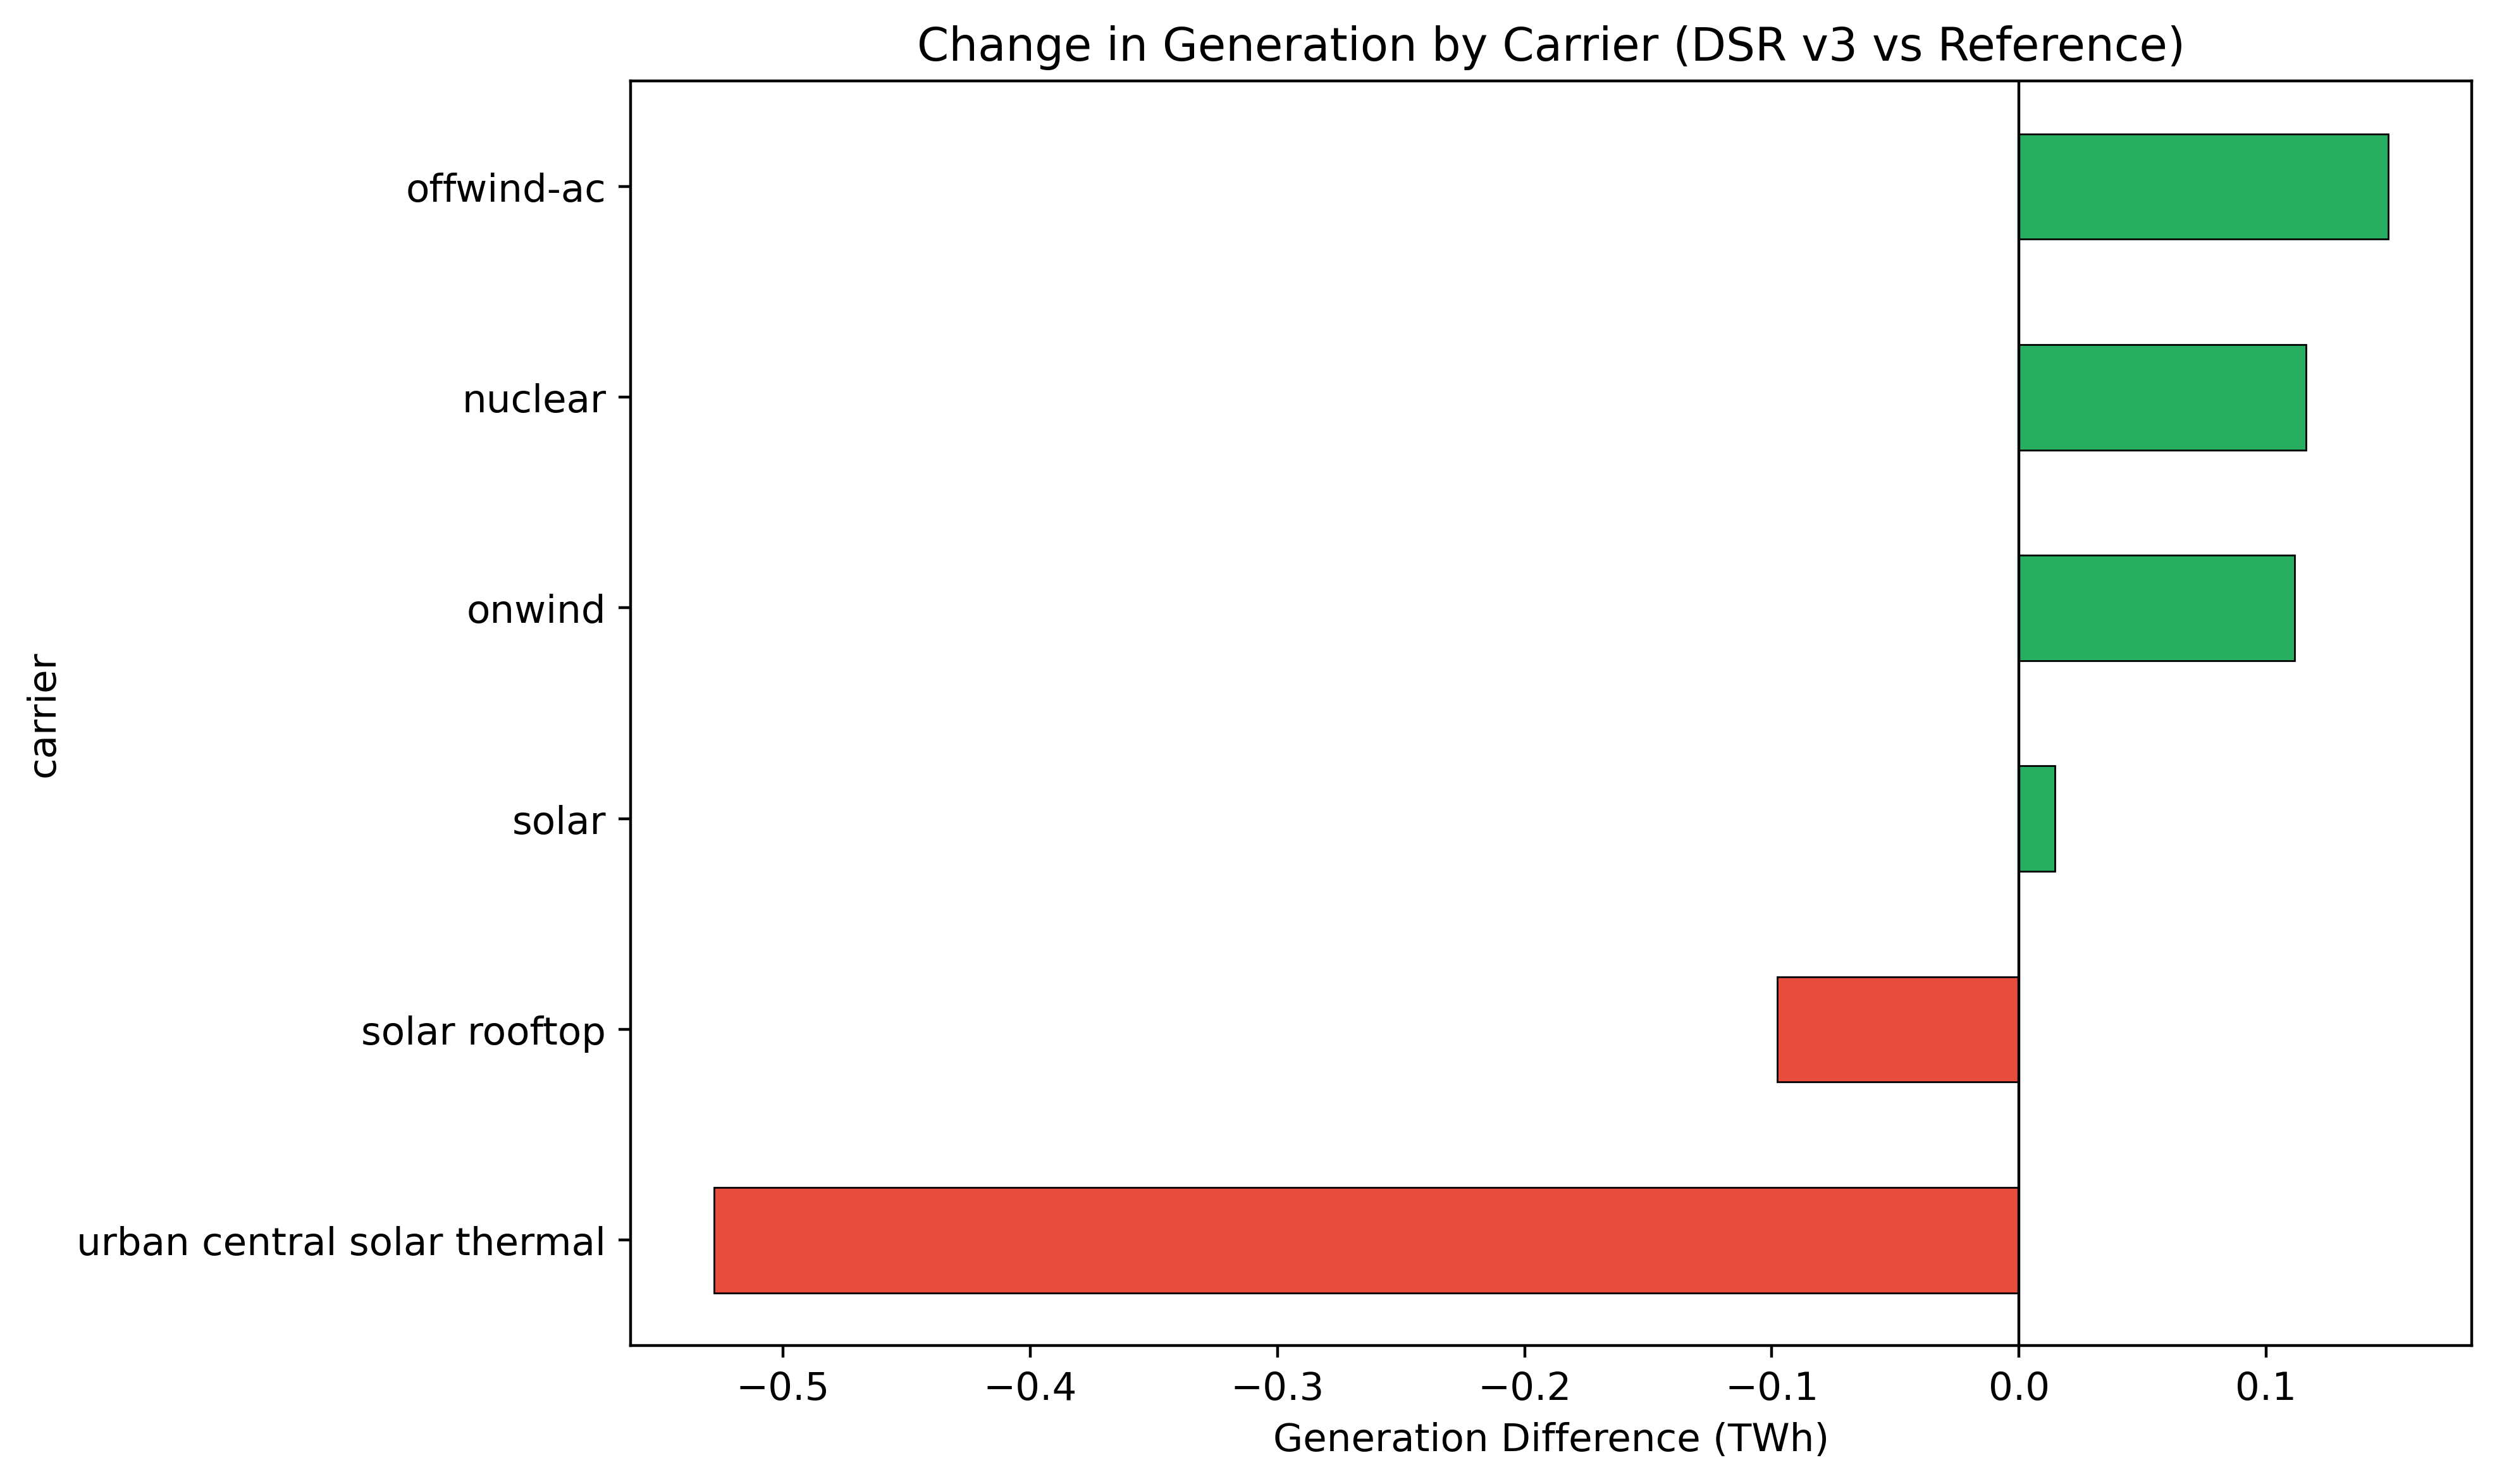

In [9]:
# Compare generation by carrier
gen_data = {}
for label, n_ in [('Reference', n_ref), ('DSR v3', n_dsr)]:
    gen_by_carrier = n_.generators_t.p.sum().groupby(n_.generators.carrier).sum() / 1e6  # TWh
    gen_data[label] = gen_by_carrier

df_gen = pd.DataFrame(gen_data).fillna(0)
df_gen['Difference'] = df_gen['DSR v3'] - df_gen['Reference']
df_gen = df_gen.sort_values('Reference', ascending=False)

# Top carriers
top = df_gen.head(15)
print('Generation by carrier (TWh):')
print(top.to_string(float_format='{:.1f}'.format))

# Plot difference
diff_nonzero = df_gen[df_gen['Difference'].abs() > 0.01]['Difference'].sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#27ae60' if v > 0 else '#e74c3c' for v in diff_nonzero.values]
diff_nonzero.plot(kind='barh', ax=ax, color=colors, edgecolor='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Generation Difference (TWh)')
ax.set_title('Change in Generation by Carrier (DSR v3 vs Reference)')
plt.tight_layout()
plt.show()

## 8. Summary

In [10]:
# Summary table
dsr_stores = n_dsr.stores[n_dsr.stores.carrier == 'industry dsr']
ch_links = n_dsr.links[n_dsr.links.carrier == 'industry dsr charge']
dch_links = n_dsr.links[n_dsr.links.carrier == 'industry dsr discharge']

re_carriers = ['solar', 'onwind', 'offwind-ac', 'offwind-dc', 'offwind-float']
curt = {}
for label, n_ in [('Reference', n_ref), ('DSR v3', n_dsr)]:
    re = n_.generators[n_.generators.carrier.isin(re_carriers)]
    pot = (n_.generators_t.p_max_pu[re.index] * re.p_nom_opt).sum().sum()
    act = n_.generators_t.p[re.index].sum().sum()
    curt[label] = (pot - act) / 1e6

summary = pd.DataFrame({
    'Metric': [
        'System Cost (B EUR/year)',
        'Average LV Price (EUR/MWh)',
        'Renewable Curtailment (TWh)',
        'DSR Capacity Built (MWh)',
        'DSR Energy Shifted (TWh)',
        'DSR Investment (M EUR/year)',
        'System Cost Savings (B EUR/year)',
    ],
    'Reference (no DSR)': [
        f'{n_ref.objective/1e9:.2f}',
        f'{avg_ref:.2f}',
        f'{curt["Reference"]:.2f}',
        'N/A',
        'N/A',
        'N/A',
        'N/A',
    ],
    'DSR v3': [
        f'{n_dsr.objective/1e9:.2f}',
        f'{avg_dsr:.2f}',
        f'{curt["DSR v3"]:.2f}',
        f'{dsr_stores.e_nom_opt.sum():.0f}',
        f'{n_dsr.links_t.p0[ch_links.index].sum().sum()/1e6:.2f}',
        f'{(dsr_stores.e_nom_opt * dsr_stores.capital_cost).sum()/1e6:.2f}',
        f'{(n_ref.objective - n_dsr.objective)/1e9:.2f}',
    ],
})

print('\n' + '='*70)
print('INDUSTRY DSR IMPACT SUMMARY')
print('='*70)
print(summary.to_string(index=False))
print('\nConclusion: DSR reduces system cost, lowers prices, and cuts curtailment.')
print('The optimizer rationally builds DSR where the arbitrage value exceeds costs.')


INDUSTRY DSR IMPACT SUMMARY
                          Metric Reference (no DSR) DSR v3
        System Cost (B EUR/year)             617.18 613.33
      Average LV Price (EUR/MWh)             112.12 111.52
     Renewable Curtailment (TWh)               1.02   0.75
        DSR Capacity Built (MWh)                N/A  60668
        DSR Energy Shifted (TWh)                N/A  10.32
     DSR Investment (M EUR/year)                N/A   0.30
System Cost Savings (B EUR/year)                N/A   3.85

Conclusion: DSR reduces system cost, lowers prices, and cuts curtailment.
The optimizer rationally builds DSR where the arbitrage value exceeds costs.
